# Extract keypoints

Indexes `datasets/`, runs jazz's palm detector and landmark net over every image,
and writes `keypoints.npz` for `experiment_mlp.ipynb`.

`palm_rois.npz` and `landmarks.npz` are resumable caches of the two slow passes,
keyed on model, device and the exact file list.

In [1]:
import hashlib
import re
import string
from collections import Counter
from pathlib import Path

import cv2

DATASETS = Path("datasets")
F2_TRAIN = DATASETS / "2/asl_alphabet_train/asl_alphabet_train"
F4_TRAIN = DATASETS / "4/ASL_Alphabet_Dataset/asl_alphabet_train"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
LETTERS = set(string.ascii_uppercase)
#dictionary: CLASS_TO_IDX['A'] = 0
CLASS_TO_IDX = {c: i for i, c in enumerate(string.ascii_uppercase)}
#good quality Z clips being used for dataset 15
Z_CLIPS = set(range(81, 147)) | set(range(177, 258)) | set(range(380, 397))


def images_in(folder):
    """Image files directly inside `folder`, in stable order.

    Skips AppleDouble sidecars (`._name.jpg`), which source 5 ships thousands of
    under __MACOSX and which are 4 KB metadata blobs, not decodable images.
    """
    return sorted(p for p in folder.iterdir()
                  if p.suffix.lower() in IMAGE_EXTS and not p.name.startswith("._"))


def letter_folders(root, keep=LETTERS):
    """(path, LABEL) for every <LETTER> folder at any depth under `root`.

    Depth-agnostic, so train/test/valid wrappers are folded into one set.
    """
    for d in sorted(p for p in root.rglob("*") if p.is_dir() and p.name.upper() in keep):
        if "__MACOSX" in d.parts:
            continue
        for img in images_in(d):
            yield img, d.name.upper()


def letter_dirs(root, keep=LETTERS, sub=""):
    """(path, LABEL) for the <LETTER> folders directly inside `root`, images taken
    from `root/<LETTER>/sub`. No recursion, so a nested copy of the set stays out.
    """
    for d in sorted(p for p in root.iterdir() if p.name.upper() in keep):
        for img in images_in(d / sub):
            yield img, d.name.upper()


def source_2():
    """Drops K, M, N, P, Q, T -- signed wrong here."""
    for img, letter in letter_dirs(F2_TRAIN, LETTERS - set("KMNPQT")):
        yield img, letter, "2"


def source_3():
    """Class folders are numbered in alphabet order: 0-25 are A-Z, 26 and 27 are not
    letters. Stopping at 24 keeps A-Y and drops Z."""
    for i, letter in enumerate(string.ascii_uppercase[:25]):
        for img in images_in(DATASETS / "3/data" / str(i)):
            yield img, letter, "3"


def source_4():
    """Drops P entirely; K, M, N, T keep no "<LETTER> (n).jpg"; J keeps no rotations.

    Five naming schemes per letter, and only three of them are original images:
    <LETTER><n>.jpg is folder 2 copied byte for byte, and <LETTER> (n).jpg is ~3000
    more folder-2 copies with new images numbered either side of them. The paren files
    are matched against folder 2 by content hash. A number range would not do: B's
    numbering has gaps, so its copied block spans 3000 numbers but 2970 files.
    Kept as original: <n>.jpg, <LETTER><n>_test.jpg and the *rotate* renders.
    Each naming scheme is its own subset -- same folder, different datasets.
    ponytail: rehashes ~144k files every run -- ~90 s cold, seconds once the page
    cache is warm. Cache the kept paths if that ever stops being true.
    """
    plain = re.compile(r"^\d+\.jpe?g$")                     # <number>.jpg
    test = re.compile(r"^[A-Za-z]\d+_test\.jpe?g$", re.I)   # <LETTER><number>_test.jpg
    paren = re.compile(r"^[A-Za-z] \(\d+\)\.jpe?g$")        # <LETTER> (number).jpg
    for letter in sorted(LETTERS - {"P"}):
        keep_paren = letter not in set("KMNT")
        copies = ({hashlib.md5(p.read_bytes()).digest()
                   for p in images_in(F2_TRAIN / letter)} if keep_paren else set())
        for p in images_in(F4_TRAIN / letter):
            if plain.match(p.name):
                subset = "4/plain"
            elif test.match(p.name):
                subset = "4/test"
            elif "rotate" in p.name and letter != "J":
                subset = "4/rotate"
            elif (keep_paren and paren.match(p.name)
                  and hashlib.md5(p.read_bytes()).digest() not in copies):
                subset = "4/paren"
            else:
                continue
            yield p, letter, subset


def source_5():
    """Train/ and Test/ are separate captures under the same folder."""
    for split in ("Train", "Test"):
        for img, letter in letter_folders(DATASETS / "5" / split):
            yield img, letter, f"5/{split}"


def source_6():
    """`asl_dataset/` holds a nested copy of itself, and its 0-9 folders are digits,
    not alphabet indexes. Taking only the top-level letter folders drops both."""
    for img, letter in letter_dirs(DATASETS / "6/asl_dataset"):
        yield img, letter, "6"


def source_9():
    """SignAlphaSet. Drops M -- signed wrong."""
    for img, letter in letter_folders(DATASETS / "9/SignAlphaSet/SignAlphaSet",
                                      LETTERS - {"M"}):
        yield img, letter, "9"


def source_9_dynamic():
    """ASL_dynamic/<LETTER>/<LETTER>_clip<N>_frames/, 10 clips per letter. Drops clips
    1 and 6 for every letter (the hand is still moving into the sign), and for D, M, Y
    keeps only clips 7-10. S was never extracted to frames, so it has no _frames
    folder to find and drops out on its own. Each clip is its own subset."""
    clip_no = re.compile(r"_clip(\d+)_frames$")
    for d in sorted((DATASETS / "9/SignAlphaSet/ASL_dynamic").rglob("*_frames")):
        letter, found = d.parent.name.upper(), clip_no.search(d.name)
        if letter not in LETTERS or found is None:
            continue
        clips = {7, 8, 9, 10} if letter in {"D", "M", "Y"} else {2, 3, 4, 5, 7, 8, 9, 10}
        if int(found.group(1)) in clips:
            for img in images_in(d):
                yield img, letter, f"9_dynamic/{d.name}"


def source_10():
    """Drops D. Roboflow export: flat folders with no class dirs, but the letter is the
    filename prefix (U7_jpg.rf.<hash>.jpg -> U), which matches the one-hot
    _classes.csv on all 1728 rows, so the csv is redundant. train/valid/test are
    separate subsets."""
    prefix = re.compile(r"^([A-Za-z])\d+_")
    keep = LETTERS - {"D"}
    for d in sorted(p for p in (DATASETS / "10").iterdir() if p.is_dir()):
        for img in images_in(d):
            found = prefix.match(img.name)
            if found and found.group(1).upper() in keep:
                yield img, found.group(1).upper(), f"10/{d.name}"


def source_11():
    """Drops D. Train_Alphabet/ and Test_Alphabet/ are separate subsets."""
    for split in ("Train_Alphabet", "Test_Alphabet"):
        for img, letter in letter_folders(DATASETS / "11" / split, LETTERS - {"D"}):
            yield img, letter, f"11/{split}"


def source_12():
    """Drops D and J."""
    for img, letter in letter_folders(
            DATASETS / "12/extracted/root/Root/Type_01_(Raw_Gesture)",
            LETTERS - {"D", "J"}):
        yield img, letter, "12"


def source_13():
    """Drops G, H, J, K, M, N, O, P, Q. Synthetic renders under `<letter>/lit/`
    (annotation/ and segmentation/ hold masks, not photos).

    Special case: these renders are stored on their side, so each one is rotated 90
    degrees clockwise and written to datasets/13_upright/ the first time it is needed.
    Later runs reuse that copy, and every other cell reads it as an ordinary image.
    First run costs ~7 min and 6.9 GB; delete the folder to redo it.
    """
    for src, letter in letter_dirs(DATASETS / "13/output/dataset",
                                   LETTERS - set("GHJKMNOPQ"), sub="lit"):
        upright = DATASETS / "13_upright" / letter / src.name
        if not upright.exists():
            upright.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(upright),
                        cv2.rotate(cv2.imread(str(src)), cv2.ROTATE_90_CLOCKWISE))
        yield upright, letter, "13"


def source_video_frames():
    """Frames extracted from video sources 15 (J, Z) and 16 (all letters).

    15 is one clip id per file (15_<LETTER>_<clip>_f....jpg); 16 is one hand
    (16_<LETTER>_<L|R>_f....jpg). Those are the subsets -- not the shared folder.
    """
    for img, label in letter_folders(DATASETS / "video_frames"):
        src, rest = img.name.split("_", 1)
        if src == "16":
            hand = rest.split("_")[1]                 # A_L_f00000 -> L
            yield img, label, f"16/{hand}"
        elif src == "15":
            letter, clip, _ = rest.split("_", 2)
            if letter == "J" or int(clip) in Z_CLIPS:
                yield img, label, f"15/{clip}"


# 1, 7, 8 and 14 are left out: 7 and 8 are poor quality, 14 is landmarks, not images.
SOURCES = {
    "2": source_2, "3": source_3, "4": source_4, "5": source_5, "6": source_6,
    "9": source_9, "9_dynamic": source_9_dynamic, "10": source_10, "11": source_11,
    "12": source_12, "13": source_13, "video_frames": source_video_frames,
}

#all samples will be processed in the upcoming cells
# third field is the subset id (finer than the SOURCES key when a folder mixes datasets)
all_samples = [(path, label, subset)
               for name, load in SOURCES.items()
               for path, label, subset in load()
               if label in LETTERS]

per_subset = Counter(sub for _, _, sub in all_samples)
per_class = Counter(lab for _, lab, _ in all_samples)
assert not [c for c in string.ascii_uppercase if not per_class[c]], \
    f"no images for {[c for c in string.ascii_uppercase if not per_class[c]]}"
print(f"{len(all_samples):,} images indexed from {len(per_subset)} subsets")
print("per subset:", "  ".join(f"{s}={n:,}" for s, n in sorted(per_subset.items())))
print("per class: ", "  ".join(f"{c}={per_class[c]:,}" for c in string.ascii_uppercase))


495,525 images indexed from 540 subsets
per subset: 10/test=71  10/train=1,449  10/valid=138  11/Test_Alphabet=2,500  11/Train_Alphabet=22,500  12=36,000  13=17,017  15/1=32  15/10=89  15/100=179  15/101=126  15/102=180  15/103=179  15/104=180  15/105=179  15/106=180  15/107=179  15/108=180  15/109=180  15/11=89  15/110=179  15/111=179  15/112=123  15/113=124  15/114=181  15/115=179  15/116=180  15/117=180  15/118=179  15/119=180  15/12=89  15/120=178  15/121=178  15/122=178  15/123=178  15/124=123  15/125=178  15/126=178  15/127=178  15/128=178  15/129=178  15/13=33  15/130=178  15/131=178  15/132=178  15/133=178  15/134=178  15/135=123  15/136=178  15/137=178  15/138=178  15/139=178  15/14=89  15/140=178  15/141=178  15/142=178  15/143=178  15/144=178  15/145=178  15/146=122  15/147=89  15/148=89  15/149=89  15/15=89  15/150=89  15/151=89  15/152=89  15/153=89  15/154=89  15/155=89  15/156=89  15/157=32  15/158=89  15/159=89  15/16=89  15/160=89  15/161=89  15/162=89  15/163=89  15/1

In [2]:
all_samples[0]

(PosixPath('datasets/2/asl_alphabet_train/asl_alphabet_train/A/A1.jpg'),
 'A',
 '2')

(np.float64(-0.5), np.float64(479.5), np.float64(639.5), np.float64(-0.5))

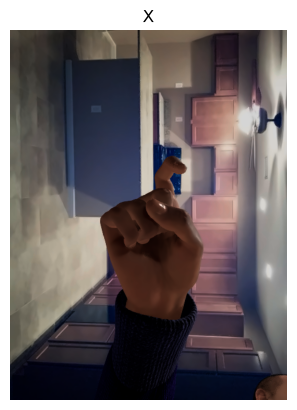

In [3]:
# Peek at what a subset actually contains: set SUBSET and CLASS, run, repeat.
# SUBSET can be an exact id ("4/plain") or a prefix ("4", "15", "9_dynamic").
import random

import matplotlib.pyplot as plt

SUBSET, CLASS = "13", "X"       # any subset id / prefix above, and any letter A-Z

paths = [p for p, label, sub in all_samples
         if label == CLASS and (sub == SUBSET or sub.startswith(SUBSET + "/"))]
assert paths, f"subset {SUBSET} has no {CLASS}"
plt.imshow(cv2.cvtColor(cv2.imread(str(random.choice(paths))), cv2.COLOR_BGR2RGB))
plt.title(CLASS)
plt.axis("off")


In [4]:
# --- Stage 1 of jazz's hand pipeline: palm detection -> rotated hand ROI --------
# The 192 detector locates the palm; its box plus two of its keypoints define a
# square ROI, rotated hand-up, exactly as jazz's GetHandRoiFromPalm builds it.
# Weights are jazz's 192 detector (tflite -> onnx -> torch), batched on GPU.
# Stage 2 (landmarks) is separate; these crops are its input format.
import math

import cv2
import numpy as np
import torch

IMG_SIZE = 224
DET_SIZE = 192
PALM_PAD = 0.3          # shrink inside the detector canvas; 0.0/0.15/0.3 measured
#                         77% / 83% / 86% detection, flat past 0.3
ROI_SCALE = 3.0                 # jazz HandDetectionConfig.roiSizeMultipleOfPalm
ROI_OFFSET = 0.33               # jazz HandDetectionConfig.roiOffsetFromPalm
UPRIGHT = (0.0, -1.0)           # jazz HandPoseDetectionEngine.uprightVec
BRANCHES = (1152, 864)          # anchors per branch; batched output is regrouped on these

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(),
      "| opencv", cv2.__version__)


def ssd_anchors(input_size=DET_SIZE, strides=(8, 16, 16, 16), offset=0.5):
    """The 2016 SsdAnchorsCalculator centres the palm boxes are regressed against."""
    anchors, n, layer = [], len(strides), 0
    while layer < n:
        last, per_cell = layer, 0
        while last < n and strides[last] == strides[layer]:
            per_cell += 2                  # one aspect ratio + one interpolated scale
            last += 1
        fm = math.ceil(input_size / strides[layer])
        for y in range(fm):
            for x in range(fm):
                anchors += [((x + offset) / fm, (y + offset) / fm)] * per_cell
        layer = last
    return np.array(anchors, np.float32)


_DETECTOR = None


def palm_detector():
    """The TorchScript detector, loaded once onto the GPU (or CPU) and reused."""
    global _DETECTOR
    if _DETECTOR is None:
        _DETECTOR = torch.jit.load("_hand_models/palm_detection_192_full.pt").to(
            "cuda" if torch.cuda.is_available() else "cpu").eval()
    return _DETECTOR


def letterbox(bgr, size, pad=0.0):
    """Aspect-preserving fit into a size x size canvas, shrunk by `pad`.

    The anchors only cover boxes up to ~75% of the frame, so a hand that fills a
    tight crop stays invisible to the detector until it is padded down.
    """
    h, w = bgr.shape[:2]
    s = size / (1.0 + pad) / max(h, w)
    nw, nh = max(1, round(w * s)), max(1, round(h * s))
    canvas = np.zeros((size, size, 3), np.uint8)
    ox, oy = (size - nw) // 2, (size - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = cv2.resize(bgr, (nw, nh), interpolation=cv2.INTER_AREA)
    return canvas, s, ox, oy


def palm_input(bgr):
    """The 192 tensor for one image, plus what is needed to map results back to it."""
    canvas, scale, ox, oy = letterbox(bgr, DET_SIZE, PALM_PAD)
    # Resize/warp/crop are per-channel, so channel order only matters here, at the
    # model boundary. Converting the 192 canvas is cheaper than the full image.
    return cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0, scale, ox, oy


def regroup(flat, n):
    """(1, n*2016, C) branch-major -> (n, 2016, C) back on the host."""
    parts, off = [], 0
    for size in BRANCHES:
        parts.append(flat[0, off:off + n * size].reshape(n, size, -1))
        off += n * size
    return torch.cat(parts, 1).cpu().numpy()


def palm_batch(bgrs):
    """Stage 1 over a list of images -> (N, 5) of score, cx, cy, side, degrees.

    One forward pass for the whole list, which is the point of being on the GPU.
    """
    prepared = [palm_input(b) for b in bgrs]
    x = torch.from_numpy(np.stack([p[0] for p in prepared])).to(
        "cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        outs = palm_detector()(x)
    # Picked by trailing dim rather than position: 18 box floats and one logit each.
    boxes = regroup(next(t for t in outs if t.shape[-1] == 18), len(bgrs))
    logits = regroup(next(t for t in outs if t.shape[-1] == 1), len(bgrs))[..., 0]
    anchors = ssd_anchors()             # once per batch: 0.7 ms, and the same every time
    return np.array([decode_palm(b, lg, anchors, *p[1:])
                     for b, lg, p in zip(boxes, logits, prepared)], np.float32)


def decode_palm(boxes, logits, anchors, scale, ox, oy):
    """Winning anchor -> (score, cx, cy, side, degrees) in original-image pixels."""
    best = int(logits.argmax())                       # sigmoid is monotonic
    score = 1.0 / (1.0 + math.exp(-float(np.clip(logits[best], -100, 100))))
    b, (ax, ay) = boxes[best], anchors[best]

    def to_px(u, v):                                  # canvas-normalised -> image px
        return ((u * DET_SIZE - ox) / scale, (v * DET_SIZE - oy) / scale)

    cx, cy = to_px(b[0] / DET_SIZE + ax, b[1] / DET_SIZE + ay)
    box_w = b[2] / scale                              # jazz sizes the ROI off width
    # GetHandRoiFromPalm: orientation is middle-finger MCP minus thumb CMC, turned
    # onto UPRIGHT, then the box centre slides along that vector by 0.33 * width.
    mx, my = to_px(b[8] / DET_SIZE + ax, b[9] / DET_SIZE + ay)     # keypoint 2
    tx, ty = to_px(b[14] / DET_SIZE + ax, b[15] / DET_SIZE + ay)   # keypoint 5
    vx, vy = mx - tx, my - ty
    norm = math.hypot(vx, vy) or 1.0
    hx, hy = vx / norm, vy / norm

    dot = max(-1.0, min(1.0, hx * UPRIGHT[0] + hy * UPRIGHT[1]))
    deg = math.degrees(math.acos(dot)) * (1.0 if UPRIGHT[0] * hy - UPRIGHT[1] * hx > 0 else -1.0)
    cx += hx * ROI_OFFSET * box_w
    cy += hy * ROI_OFFSET * box_w
    return score, cx, cy, box_w * ROI_SCALE, deg

torch 2.13.0+cu130 | cuda: True | opencv 4.13.0


In [5]:
# Stage 1 runs over everything ONCE: images with no palm are thrown away here, so the
# split in the next cell only ever sees images the detector actually found a hand in.
import hashlib
from pathlib import Path

import cv2
import numpy as np
import torch
from tqdm.auto import tqdm

RESUME_PALM_CACHE = True    # False = ignore palm cache and rescan from scratch
MIN_PALM_SCORE = 0           # jazz HandDetectionConfig.palmConfidenceThreshold
ROI_CACHE = Path("palm_rois.npz")
SCAN_BATCH = 256                # images per forward pass
CHECKPOINT = 20_000             # rows between cache writes

#scan_palms will call palm_batch
#palm_batch will call palm_input palm_detector regroup, ssd_anchors, and decode_palm
#palm_input will call letterbox
def scan_palms(items):
    """(N, 5) array of score, cx, cy, side, degrees -- cached, since it is the slow pass.

    Resumable. The cache records how many rows are finished and is rewritten every
    CHECKPOINT rows, so interrupting the kernel costs at most the images scanned since
    the last write; rerun the cell and it picks up from there. Unreadable images keep
    their zero row, so a score of 0 drops them below.
    """
    paths = [str(p) for p, _, _ in items]
    # Model, device and the exact file list are all in the key. Any of them changing
    # changes the rows -- cpu and gpu differ by ~0.3% on the boxes -- and silently
    # resuming across that would poison the run.
    key = hashlib.sha256("\n".join(["palm_detection_192_full.pt",
                                    "cuda" if torch.cuda.is_available() else "cpu",
                                    *paths]).encode()).hexdigest()

    out, start = np.zeros((len(paths), 5), np.float32), 0
    if RESUME_PALM_CACHE and ROI_CACHE.exists():
        cached = np.load(ROI_CACHE)
        if str(cached["key"]) == key:
            out, start = cached["rois"], int(cached["done"])
    if start >= len(paths):
        return out

    def save(done):
        np.savez(ROI_CACHE, key=key, rois=out, done=done)

    saved = start
    with tqdm(total=len(paths), initial=start, desc="palm scan", unit="img") as bar:
        for done in range(start, len(paths), SCAN_BATCH):
            chunk = paths[done:done + SCAN_BATCH]

            # Read the batch. An unreadable file is left out of the batch, and its row
            # stays all zeros, so its score of 0 drops it later. `rows` remembers which
            # row of `out` each image that WAS read belongs to.
            images = []
            rows = []
            for i in range(len(chunk)):
                image = cv2.imread(chunk[i])
                if image is not None:
                    images.append(image)
                    rows.append(done + i)

            if len(images) > 0:
                found = palm_batch(images)
                for i in range(len(rows)):
                    out[rows[i]] = found[i]

            bar.update(len(chunk))
            if done - saved >= CHECKPOINT:
                save(done)
                saved = done
    save(len(paths))
    return out

############ this is the line when all samples are processed
rois = scan_palms(all_samples)

/home/thanponmaiseaumsook/kaggle-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
#detected[i] = 0:path 1:class 2:group 3 and 4 : roi center coordinate 5: roi square length 6: rotation for upright
detected = [(p, lab, src, *roi[1:]) for (p, lab, src), roi in zip(all_samples, rois)
            if roi[0] >= MIN_PALM_SCORE]

print(f"{len(all_samples):,} indexed -> {len(detected):,} with a palm "
      f"({len(detected) / len(all_samples):.1%})")

495,525 indexed -> 495,525 with a palm (100.0%)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

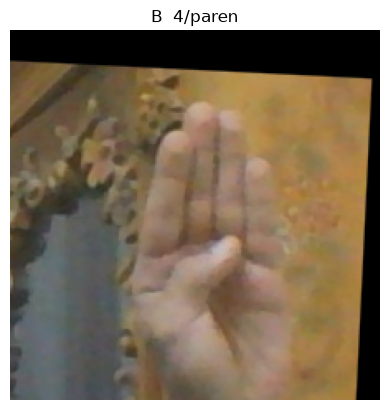

In [7]:
# Peek the palm ROI for a subset: set SUBSET and CLASS, run, repeat.
# detected item = (path, label, subset, cx, cy, side, deg)
import random

import matplotlib.pyplot as plt

SUBSET, CLASS = "4/paren", "B"
# e.g. "2", "3",
#      "4/plain", "4/test", "4/paren", "4/rotate",
#      "5/Train", "5/Test",
#      "6", "9", "9_dynamic/<LETTER>_clip<N>_frames",
#      "10/train", "10/valid", "10/test",
#      "11/Train_Alphabet", "11/Test_Alphabet",
#      "12", "13",
#      "15/<clip>", "16/L", "16/R"
# (prefix also works: "4", "5", "9_dynamic", "10", "11", "15", "16")

hits = [item for item in detected
        if item[1] == CLASS
        and (item[2] == SUBSET or item[2].startswith(SUBSET + "/"))]
assert hits, f"subset {SUBSET} has no {CLASS} past the palm gate"

path, label, subset, cx, cy, side, deg = random.choice(hits)
bgr = cv2.imread(str(path))
m = cv2.getRotationMatrix2D((cx, cy), deg, IMG_SIZE / side)
m[0, 2] += IMG_SIZE / 2 - cx
m[1, 2] += IMG_SIZE / 2 - cy
rgb = cv2.cvtColor(cv2.warpAffine(bgr, m, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(f"{label}  {subset}")
plt.axis("off")


In [46]:
detected[0][3]

np.float32(120.019165)

In [8]:
# Split per (class, subset): each letter from each subset puts the same 20% into
# val. Subsets are the third field from cell 1 -- naming schemes inside folder 4,
# Train/Test wrappers, video clips/hands, etc. -- not the coarse SOURCES key.
# Only images that cleared the palm gate above are split.
import random
import string
from collections import defaultdict

import cv2
import torch
from torch.utils.data import DataLoader, Dataset

BATCH_SIZE = 256
VAL_SHARE = 0.2

#dictionary of list: the key value can be anything tho
by_class_subset = defaultdict(list)
for item in detected:
    by_class_subset[(item[1], item[2])].append(item)

rng = random.Random(0)
train_samples, val_samples = [], []
for (label, subset), items in sorted(by_class_subset.items()):
    rng.shuffle(items)
    n_val = int(len(items) * VAL_SHARE)
    val_samples += items[:n_val]
    train_samples += items[n_val:]


def crop_roi(bgr, cx, cy, side, deg, size=IMG_SIZE):
    """The ROI square as a size x size RGB image: one warp does rotate+scale+shift."""
    m = cv2.getRotationMatrix2D((cx, cy), deg, size / side)
    m[0, 2] += size / 2 - cx
    m[1, 2] += size / 2 - cy
    warped = cv2.warpAffine(bgr, m, (size, size), flags=cv2.INTER_LINEAR)
    return cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)


class SignImages(Dataset):
    """Decodes and crops to the palm ROI found in the scan above."""

    def __init__(self, items, img_size=IMG_SIZE):
        self.items = items
        self.img_size = img_size

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, label, _, cx, cy, side, deg = self.items[i]
        bgr = cv2.imread(str(path))
        if bgr is None:
            raise FileNotFoundError(f"unreadable image: {path}")
        rgb = crop_roi(bgr, cx, cy, side, deg, self.img_size)
        return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0, CLASS_TO_IDX[label]


train_dataset = SignImages(train_samples)
val_dataset = SignImages(val_samples)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        pin_memory=torch.cuda.is_available())

print(f"{len(train_samples):,} train / {len(val_samples):,} val "
      f"across {len(by_class_subset)} class-subset buckets")


396,890 train / 98,635 val across 1121 class-subset buckets


batch (256, 3, 224, 224) torch.float32  range 0.00-1.00


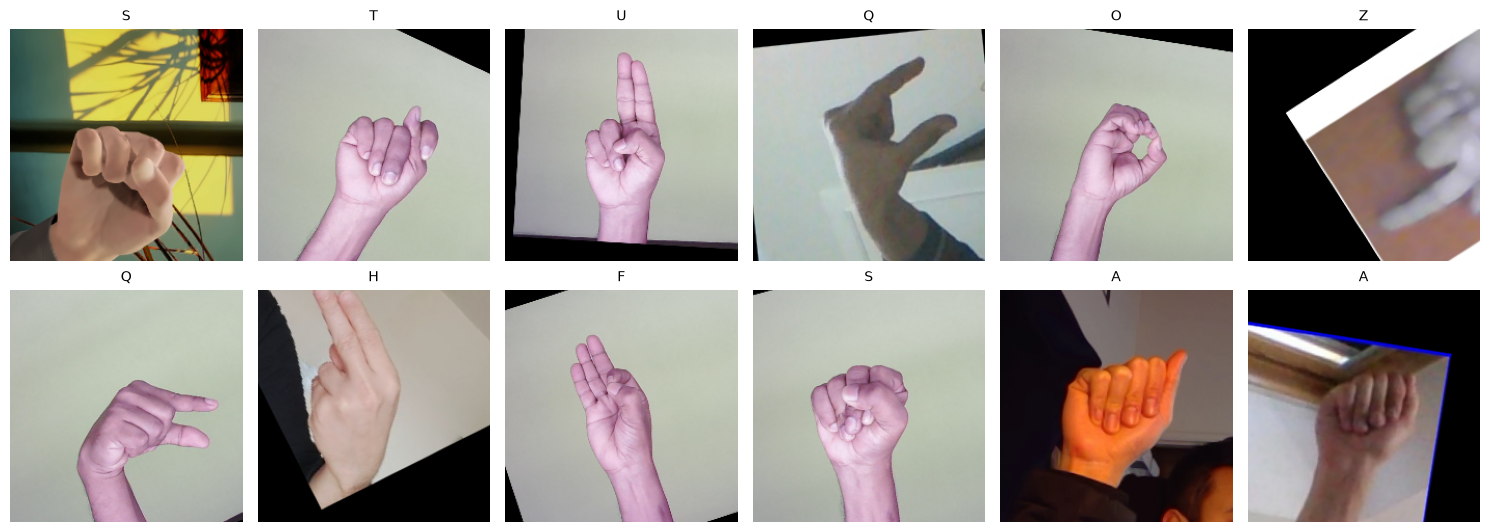

In [9]:
# Eyeball one batch: every crop should be a hand, upright and roughly the same size.
# A batch is already (N, 3, 224, 224), which is the landmark model's input shape, so
# the keypoint pass is one batched invoke per batch whenever it gets added.
import string

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print(f"batch {tuple(images.shape)} {images.dtype}  "
      f"range {images.min():.2f}-{images.max():.2f}")

fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, img, lab in zip(axes.ravel(), images, labels):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(string.ascii_uppercase[lab], fontsize=10)
    ax.axis("off")
plt.tight_layout()

In [10]:
# --- Stage 2: the crops -> 21 hand keypoints ----------------------------------
# jazz's default landmark net, batched on GPU (native batching, no regroup).
import hashlib
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

RESUME_KP_CACHE = True      # False = ignore landmark cache and re-extract
#kp = 2d world = 3d presence = hand confidence handed= l/r
_KP_FIELDS = ("kp", "world", "presence", "handed")

_LANDMARKER = None


def landmarker():
    """The TorchScript landmark net, loaded once onto the GPU (or CPU) and reused."""
    global _LANDMARKER
    if _LANDMARKER is None:
        _LANDMARKER = torch.jit.load("_hand_models/hand_landmark_224_full.pt").to(
            "cuda" if torch.cuda.is_available() else "cpu").eval()
    return _LANDMARKER

# this func will call landmarker()
def landmarks_of(images):
    """(N, 3, 224, 224) in [0,1] -> keypoints, world, presence, raw handedness.

    Head order is the MediaPipe one the onnx declares and hand-pose's loader
    confirms: Identity, Identity_1, Identity_2, Identity_3 = landmarks, presence,
    handedness, world. Both coordinate heads keep the scale hand-pose baked in:
    kp is 0-1 of the crop, world is xyz_normalized * 13. Normalized downstream.
    """
    with torch.no_grad():
        out = landmarker()(images.permute(0, 2, 3, 1).to(              # the net wants NHWC
            "cuda" if torch.cuda.is_available() else "cpu"))
    return (out[0].reshape(-1, 21, 3).cpu().numpy(),
            out[3].reshape(-1, 21, 3).cpu().numpy(),
            out[1].reshape(-1).cpu().numpy(),
            out[2].reshape(-1).cpu().numpy())


#extract_keypoints call landmarks_of
def extract_keypoints(dataset):
    """Run stage 2 over a whole dataset, in order, so row i is that dataset's item i."""
    n = len(dataset)
    kp = np.zeros((n, 21, 3), np.float32)
    world = np.zeros((n, 21, 3), np.float32)
    presence = np.zeros(n, np.float32)
    handed = np.zeros(n, np.float32)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        pin_memory=torch.cuda.is_available())
    at = 0
    for images, _ in tqdm(loader, desc="landmarks", unit="batch"):
        batch = landmarks_of(images)
        for dst, src in zip((kp, world, presence, handed), batch):
            dst[at:at + len(src)] = src
        at += len(batch[0])
    return kp, world, presence, handed


# Same cache rule as the palm scan: model, device and the exact file list are the key.
_KP_KEY = hashlib.sha256("\n".join(
    ["hand_landmark_224_full.pt", "cuda" if torch.cuda.is_available() else "cpu",
     *_KP_FIELDS] + [str(i[0]) for i in train_samples + val_samples]
).encode()).hexdigest()

if (RESUME_KP_CACHE and Path("landmarks.npz").exists()
        and str(np.load("landmarks.npz")["key"]) == _KP_KEY):
    _z = np.load("landmarks.npz")
    train_kp, train_world, train_presence, train_handed = (
        _z["train_kp"], _z["train_world"], _z["train_presence"], _z["train_handed"])
    val_kp, val_world, val_presence, val_handed = (
        _z["val_kp"], _z["val_world"], _z["val_presence"], _z["val_handed"])
else:
    train_kp, train_world, train_presence, train_handed = extract_keypoints(train_dataset)
    val_kp, val_world, val_presence, val_handed = extract_keypoints(val_dataset)
    np.savez("landmarks.npz", key=_KP_KEY,
             train_kp=train_kp, train_world=train_world,
             train_presence=train_presence, train_handed=train_handed,
             val_kp=val_kp, val_world=val_world,
             val_presence=val_presence, val_handed=val_handed)


In [10]:
# Eyeball stage 2: the skeleton should sit on the hand, not float beside it.
# Nothing here runs the model -- every number drawn is read back out of landmarks.npz,
# so a skeleton in the wrong place means the cache is stale or out of step with the
# split, not that the landmark net missed. Set the knobs, run, repeat.
import matplotlib.pyplot as plt
import numpy as np

SPLIT = "train"                       # "train" or "val"
SUBSET, CLASS = "12", "D"
# e.g. "2", "3",
#      "4/plain", "4/test", "4/paren", "4/rotate",
#      "5/Train", "5/Test",
#      "6", "9", "9_dynamic/<LETTER>_clip<N>_frames",
#      "10/train", "10/valid", "10/test",
#      "11/Train_Alphabet", "11/Test_Alphabet",
#      "12", "13",
#      "15/<clip>", "16/L", "16/R"
# (prefix also works: "4", "5", "9_dynamic", "10", "11", "15", "16")
PRESENCE, HANDEDNESS = 0.8, 0.8     # wanted: the nearest cached pair wins, e.g. 0.498
FINGERS = [(0, 1, 2, 3, 4), (0, 5, 6, 7, 8), (0, 9, 10, 11, 12),
           (0, 13, 14, 15, 16), (0, 17, 18, 19, 20)]


def handedness(raw):
    """jazz's rule, MediaPipeHandLandmarkDetector.cs, unrounded: 1 - raw, 0=Left 1=Right.

    jazz rounds this to a side; the float is kept here because how far it sits from
    0.5 is the whole question. It stays a function over the raw score rather than
    baked into the arrays, because the label is only as trustworthy as the mirroring:
    jazz reads a selfie camera, and a dataset shot un-mirrored flips the answer.
    """
    return 1.0 - raw


_cached = np.load("landmarks.npz")
assert str(_cached["key"]) == _KP_KEY, "landmarks.npz is stale -- rerun the cell above"
items = train_samples if SPLIT == "train" else val_samples
presence, handed = _cached[f"{SPLIT}_presence"], handedness(_cached[f"{SPLIT}_handed"])

rows = [i for i, item in enumerate(items)
        if item[1] == CLASS and (item[2] == SUBSET or item[2].startswith(SUBSET + "/"))]
assert rows, f"subset {SUBSET} has no {CLASS} in {SPLIT}"
# Both knobs pull on the same pick, so the winner is the smallest total miss.
i = min(rows, key=lambda r: abs(presence[r] - PRESENCE) + abs(handed[r] - HANDEDNESS))

path, label, subset, cx, cy, side, deg = items[i]
pts = _cached[f"{SPLIT}_kp"][i][:, :2] * IMG_SIZE     # cached 0-1 of the crop -> pixels
plt.imshow(crop_roi(cv2.imread(str(path)), cx, cy, side, deg))
for finger in FINGERS:
    plt.plot(pts[list(finger), 0], pts[list(finger), 1], "-", lw=1.2, c="lime")
plt.scatter(pts[:, 0], pts[:, 1], s=6, c="red", zorder=3)
plt.title(f"{label}  {subset}  {SPLIT}[{i}]\n"
          f"presence {presence[i]:.3f}   handedness {handed[i]:.3f} "
          f"({'L' if handed[i] < 0.5 else 'R'})", fontsize=10)
plt.axis("off")

AssertionError: subset 12 has no D in train

In [ ]:
# One letter across every subset that has it: 5 crops each, straight off the cache
# opened above. Presence, palm score and handedness are all bands: widen them to see
# the letter at its best, narrow them onto a weak band to see what a gate would throw
# away, and tell a subset that is bad data from one that is only badly cropped.
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

CLASS = "G"
PER_SUBSET = 5
MIN_PRESENCE, MAX_PRESENCE = 0.9, 1.0
MIN_PALM, MAX_PALM = 0.8, 1
MIN_HAND, MAX_HAND = 0,0.3    # from 0 or 1: 0.1-0.3 also keeps 0.7-0.9

items = train_samples + val_samples          # the split does not matter for eyeballing
kp = np.concatenate([_cached["train_kp"], _cached["val_kp"]])
presence = np.concatenate([_cached["train_presence"], _cached["val_presence"]])
handed = handedness(np.concatenate([_cached["train_handed"], _cached["val_handed"]]))
# The palm score is the one number `detected` drops, so it comes back by path.
palm = {str(p): roi[0] for (p, lab, _), roi in zip(all_samples, rois) if lab == CLASS}

eligible = defaultdict(list)
for r, item in enumerate(items):
    if (item[1] == CLASS
            and MIN_PRESENCE <= presence[r] <= MAX_PRESENCE
            and MIN_PALM <= palm[str(item[0])] <= MAX_PALM
            and MIN_HAND <= min(handed[r], 1 - handed[r]) <= MAX_HAND):
        eligible[item[2]].append(r)
assert eligible, f"no {CLASS} sits in those presence, palm and handedness bands"

# Sorted by hand then presence, so evenly spaced picks walk both hands and the whole
# presence range instead of landing on five near-identical frames.
picks = {}
for subset, rows in sorted(eligible.items()):
    rows.sort(key=lambda r: (handed[r] > 0.5, presence[r]))
    spread = np.linspace(0, len(rows) - 1, min(PER_SUBSET, len(rows))).round()
    picks[subset] = [rows[j] for j in spread.astype(int)]

print(f"{CLASS}: {sum(len(r) for r in picks.values())} crops from {len(picks)} subsets")

fig, axes = plt.subplots(len(picks), PER_SUBSET, squeeze=False,
                         figsize=(2.2 * PER_SUBSET, 2.5 * len(picks)))
for ax_row, (subset, rows) in zip(axes, picks.items()):
    ax_row[0].set_ylabel(subset, fontsize=8)
    for ax in ax_row[len(rows):]:
        ax.axis("off")
    for ax, r in zip(ax_row, rows):
        path, label, _, cx, cy, side, deg = items[r]
        pts = kp[r][:, :2] * IMG_SIZE
        ax.imshow(crop_roi(cv2.imread(str(path)), cx, cy, side, deg))
        for finger in FINGERS:
            ax.plot(pts[list(finger), 0], pts[list(finger), 1], "-", lw=1.0, c="lime")
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(f"palm={palm[str(path)]:.2f}  p={presence[r]:.2f}  "
                     f"h={handed[r]:.2f}", fontsize=8)
plt.tight_layout()

In [127]:
# What a set of gates would keep, over the same arrays the cell above builds.
# Every knob is a range, and a full range means "do not care".
PALM = (0.8, 1.0)
CONFIDENCE = (0.9, 1.0)
HAND = (0.0, 0.3)               # from 0 or 1: 0.1-0.3 also keeps 0.7-0.9

palm_of = dict(zip((str(p) for p, _, _ in all_samples), rois[:, 0]))
palm = np.array([palm_of[str(item[0])] for item in items])
off = np.minimum(handed, 1 - handed)            # 0.85 counts as 0.15
keep = ((PALM[0] <= palm) & (palm <= PALM[1])
        & (CONFIDENCE[0] <= presence) & (presence <= CONFIDENCE[1])
        & (HAND[0] <= off) & (off <= HAND[1]))
print(f"{keep.sum():,} of {len(keep):,} images kept ({keep.mean():.2%})")

401,783 of 495,525 images kept (81.08%)


In [ ]:
import numpy as np

np.set_printoptions(suppress=True, precision=4)
train_kp[1006]

In [26]:
# --- Save keypoints.npz -----------------------------------------------------------
# Train and val: only rows inside the gate bands from the counter cell above.
# Test: signlanguagetestdata/, jazz defaults. Arrays are raw model output -- no *224,
# no /13.
import hashlib
import string
from pathlib import Path

import cv2
import numpy as np
from tqdm.auto import tqdm

PALM = (0.8, 1.0)
CONFIDENCE = (0.9, 1.0)
HAND = (0.0, 0.3)

TEST_PALM = 0.5                 # jazz HandPoseDetector.prefab palmConfidenceThreshold
TEST_MIN_PRESENCE = 0.5         # jazz HandPoseDetector.prefab handPoseConfidenceThreshold

TEST_ROOT = Path("signlanguagetestdata")
KEYPOINTS = Path("keypoints.npz")
RESUME_KEYPOINTS_CACHE = True   # False = re-filter and overwrite keypoints.npz

palm_of = dict(zip((str(p) for p, _, _ in all_samples), rois[:, 0]))

_lm = np.load("landmarks.npz")
assert str(_lm["key"]) == _KP_KEY, "landmarks.npz stale -- rerun cell 13"
train_kp, train_world, train_presence, train_handed = (
    _lm["train_kp"], _lm["train_world"], _lm["train_presence"], _lm["train_handed"])
val_kp, val_world, val_presence, val_handed = (
    _lm["val_kp"], _lm["val_world"], _lm["val_presence"], _lm["val_handed"])


def gate_mask(samples, presence, handed_raw):
    palm = np.array([palm_of[str(item[0])] for item in samples], np.float32)
    off = np.minimum(handedness(handed_raw), 1 - handedness(handed_raw))
    return ((PALM[0] <= palm) & (palm <= PALM[1])
            & (CONFIDENCE[0] <= presence) & (presence <= CONFIDENCE[1])
            & (HAND[0] <= off) & (off <= HAND[1]))


def take(samples, kp, world, presence, handed, labels, keep):
    keep = np.flatnonzero(keep)
    items = [samples[i] for i in keep]
    return (items,
            kp[keep], world[keep], presence[keep], handed[keep],
            labels[keep], np.array([item[-1] for item in items], np.float32))


test_samples = [(p, lab, hand) for hand in ("left", "right")
                for p, lab in letter_folders(TEST_ROOT / hand)]
_TEST_KEY = hashlib.sha256("\n".join(
    ["palm_detection_192_full.pt", "hand_landmark_224_full.pt",
     f"palm={TEST_PALM}", f"presence={TEST_MIN_PRESENCE}",
     "cuda" if torch.cuda.is_available() else "cpu"] + [str(p) for p, _, _ in test_samples]
).encode()).hexdigest()
_KEYPOINTS_KEY = hashlib.sha256("\n".join([
    str(_lm["key"]), repr(PALM), repr(CONFIDENCE), repr(HAND),
    f"test_palm={TEST_PALM}", f"test_pres={TEST_MIN_PRESENCE}", _TEST_KEY,
]).encode()).hexdigest()

_cached = np.load(KEYPOINTS) if KEYPOINTS.exists() else None
_legacy = (_cached is not None and "train_paths" in _cached.files
           and len(_cached["train_kp"]) > 0)
if (RESUME_KEYPOINTS_CACHE and _cached is not None
        and (("key" in _cached.files and str(_cached["key"]) == _KEYPOINTS_KEY) or _legacy)):
    train_kp, train_world, train_presence, train_handed = (
        _cached["train_kp"], _cached["train_world"],
        _cached["train_presence"], _cached["train_handed"])
    train_deg, train_labels = _cached["train_deg"], _cached["train_labels"]
    train_paths, train_subset = _cached["train_paths"], _cached["train_subset"]
    val_kp, val_world, val_presence, val_handed = (
        _cached["val_kp"], _cached["val_world"],
        _cached["val_presence"], _cached["val_handed"])
    val_deg, val_labels = _cached["val_deg"], _cached["val_labels"]
    val_paths, val_subset = _cached["val_paths"], _cached["val_subset"]
    test_kp, test_world, test_presence, test_handed = (
        _cached["test_kp"], _cached["test_world"],
        _cached["test_presence"], _cached["test_handed"])
    test_deg, test_labels, test_left = (
        _cached["test_deg"], _cached["test_labels"], _cached["test_left"])
    test_paths, test_subset = _cached["test_paths"], _cached["test_subset"]
    test_labelled, test_detected = int(_cached["test_labelled"]), int(_cached["test_detected"])
    print(f"resumed {KEYPOINTS}" + (" (legacy, no key yet)" if _legacy else ""))
else:
    train_labels = np.array([CLASS_TO_IDX[lab] for _, lab, *_ in train_samples], np.int64)
    val_labels = np.array([CLASS_TO_IDX[lab] for _, lab, *_ in val_samples], np.int64)
    train_items, train_kp, train_world, train_presence, train_handed, train_labels, train_deg = take(
        train_samples, train_kp, train_world, train_presence, train_handed, train_labels,
        gate_mask(train_samples, train_presence, train_handed))
    val_items, val_kp, val_world, val_presence, val_handed, val_labels, val_deg = take(
        val_samples, val_kp, val_world, val_presence, val_handed, val_labels,
        gate_mask(val_samples, val_presence, val_handed))
    train_paths = np.array([str(p) for p, _, *_ in train_items])
    train_subset = np.array([sub for _, _, sub, *_ in train_items])
    val_paths = np.array([str(p) for p, _, *_ in val_items])
    val_subset = np.array([sub for _, _, sub, *_ in val_items])

    def scan_rois(paths):
        """Stage 1 over a path list, no cache -> (N, 5). Unreadable images keep a zero row."""
        out = np.zeros((len(paths), 5), np.float32)
        for at in tqdm(range(0, len(paths), SCAN_BATCH), desc="test palm", unit="batch"):
            chunk = paths[at:at + SCAN_BATCH]
            images, rows = [], []
            for i, p in enumerate(chunk):
                image = cv2.imread(str(p))
                if image is not None:
                    images.append(image)
                    rows.append(at + i)
            if images:
                for row, roi in zip(rows, palm_batch(images)):
                    out[row] = roi
        return out

    rois_test = scan_rois([p for p, _, _ in test_samples])
    past_palm = [(p, lab, hand, *roi[1:]) for (p, lab, hand), roi
                 in zip(test_samples, rois_test) if roi[0] >= TEST_PALM]
    test_kp, test_world, test_presence, test_handed = extract_keypoints(SignImages(past_palm))
    test_labels = np.array([CLASS_TO_IDX[lab] for _, lab, *_ in past_palm], np.int64)
    test_left = np.array([hand == "left" for _, _, hand, *_ in past_palm])
    test_deg = np.array([item[-1] for item in past_palm], np.float32)
    test_keep = test_presence >= TEST_MIN_PRESENCE   # jazz rounds handedness; no band filter
    past_palm = [past_palm[i] for i in np.flatnonzero(test_keep)]
    test_kp, test_world, test_presence, test_handed = (
        test_kp[test_keep], test_world[test_keep],
        test_presence[test_keep], test_handed[test_keep])
    test_labels, test_left, test_deg = (
        test_labels[test_keep], test_left[test_keep], test_deg[test_keep])
    test_paths = np.array([str(p) for p, _, *_ in past_palm])
    test_subset = np.array([f"test/{hand}" for _, _, hand, *_ in past_palm])
    test_labelled, test_detected = len(test_samples), len(test_kp)

    np.savez(KEYPOINTS, key=_KEYPOINTS_KEY, test_key=_TEST_KEY,
             classes=np.array(list(string.ascii_uppercase)),
             train_kp=train_kp, train_world=train_world,
             train_presence=train_presence, train_handed=train_handed,
             train_deg=train_deg, train_labels=train_labels,
             train_paths=train_paths, train_subset=train_subset,
             val_kp=val_kp, val_world=val_world,
             val_presence=val_presence, val_handed=val_handed,
             val_deg=val_deg, val_labels=val_labels,
             val_paths=val_paths, val_subset=val_subset,
             test_kp=test_kp, test_world=test_world,
             test_presence=test_presence, test_handed=test_handed,
             test_deg=test_deg, test_labels=test_labels, test_left=test_left,
             test_paths=test_paths, test_subset=test_subset,
             test_labelled=test_labelled, test_detected=test_detected)
    print(f"saved -> {KEYPOINTS}")

print(f"train {len(train_kp):,} / val {len(val_kp):,} past your gates")
print(f"test  {test_labelled:,} labelled -> {test_detected:,} past jazz gates "
      f"({test_left.mean():.1%} left by folder)")


resumed keypoints.npz (legacy, no key yet)
train 321,697 / val 80,086 past your gates
test  28,088 labelled -> 25,098 past jazz gates (48.4% left by folder)


In [27]:
import numpy as np

z = np.load("keypoints.npz")


In [28]:
print(z.files)

['test_key', 'classes', 'train_kp', 'train_world', 'train_presence', 'train_handed', 'train_deg', 'train_labels', 'train_paths', 'train_subset', 'val_kp', 'val_world', 'val_presence', 'val_handed', 'val_deg', 'val_labels', 'val_paths', 'val_subset', 'test_kp', 'test_world', 'test_presence', 'test_handed', 'test_deg', 'test_labels', 'test_left', 'test_paths', 'test_subset', 'test_labelled', 'test_detected']


In [35]:
z["train_kp"][:,:,2].max()

np.float32(0.27532306)

In [41]:
z["train_world"][:,:,2].max()

np.float32(1.8815055)

In [45]:
z["train_deg"].min()

np.float32(-179.98022)